# ***Import bibliotheques***

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns


# ***Definir Fonction qui permet de faire la comparaison des algorithmes***
- **Regression Logistique**
- **Naive Bayes**
- **KNN**
- **Decision Tree**

In [3]:

def comparer_modeles(X, y, test_size=0.25, random_state=42, cv=5):
    
    """
    Compare les performances de 4 algorithmes de classification
    
    Parameters:
    -------------------------------------------------------------
    X : array-like, features
    y : array-like, target
    test_size : float, proportion pour le test set
    random_state : int, pour la reproductibilité
    cv : int, nombre de folds pour la validation croisée
    
    Returns:
    ------------------------------------------------------------
    df_scores : DataFrame avec les métriques de performance
    modeles : dict contenant les modèles entraînés
    """
    
    # Division des données
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # Standardisation des features (important pour KNN et Regression Logistique)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Définition des modèles
    modeles = {
        'Regression Logistique': LogisticRegression(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=5)
    }
    
    # Stockage des résultats
    results = []
    modeles_entraines = {}
    
    for nom_modele, modele in modeles.items():
        print(f"🔍 Entraînement de {nom_modele}...")
        
        # Choix des données (scaled(KNN,Regression Logistique) ou non) 
        if nom_modele in ['Regression Logistique', 'KNN']:
            X_train_used = X_train_scaled
            X_test_used  = X_test_scaled
        else:
            X_train_used = X_train
            X_test_used  = X_test
        
        # Entraînement du modèle
        modele.fit(X_train_used, y_train)
        
        # Prédictions
        y_pred = modele.predict(X_test_used)
        
        # Calcul des métriques
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Validation croisée
        cv_scores = cross_val_score(modele, X_train_used, y_train, cv=cv, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()
        
        # Stockage des résultats
        resultat = {
            'Modèle': nom_modele,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'CV Accuracy Mean': round(cv_mean, 4),
            'CV Accuracy Std': round(cv_std, 4)
        }
        
        results.append(resultat)
        modeles_entraines[nom_modele] = modele
        
        print(f"✅ {nom_modele} terminé - Accuracy: {accuracy:.4f}")
    
    # Création du DataFrame de résultats
    df_scores = pd.DataFrame(results)
    
    return df_scores, modeles_entraines, (X_test, y_test)

# ***Définir fonction qui permet de visualiser la comparaison des modeles***

In [12]:

def visualiser_resultats(df_scores):
    
    """
    Visualise les résultats de comparaison des modèles
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Graphique 1: Accuracy et F1-Score
    metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    x = range(len(df_scores))
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in df_scores.columns:
            axes[0, 0].bar([p + i*0.2 for p in x], df_scores[metric], width=0.2, label=metric)
    
    axes[0, 0].set_title('Comparaison des Métriques Principales')
    axes[0, 0].set_xlabel('Modèles')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_xticks([p + 0.3 for p in x])
    axes[0, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
        
    # Graphique 3: Validation croisée
    axes[1, 0].bar(df_scores['Modèle'], df_scores['CV Accuracy Mean'], 
                   yerr=df_scores['CV Accuracy Std'], capsize=5, alpha=0.7, color='green')
    axes[1, 0].set_title('Accuracy - Validation Croisée (Mean ± Std)')
    axes[1, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Heatmap des performances
    metrics_df = df_scores.set_index('Modèle')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', ax=axes[1, 1])
    axes[1, 1].set_title('Heatmap des Performances')
    
    plt.tight_layout()
    plt.show()
    
    # Affichage du tableau des scores
    print("📊 TABLEAU COMPARATIF DES PERFORMANCES")
    print("="*80)
    display(df_scores.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, ['Accuracy', 'F1-Score']]))
    
    return df_scores

# ***Péparation des données***

In [16]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
91204,20.0,-12.0,0.0,9.4,71.0,0.0,4,1,1020.0,6
49249,12.0,-3.5,0.0,1.0,91.0,100.0,0,1,1125.0,7
694723,42.0,26.2,0.0,3.5,53.0,100.0,2,7,975.0,5
588894,7.0,17.4,1.0,15.9,80.0,100.0,1,6,30.0,1
527416,7.0,9.6,0.0,12.8,76.0,100.0,4,5,855.0,5
225109,0.0,-0.1,0.0,17.7,82.0,100.0,5,3,465.0,2
26367,2.0,-8.4,0.0,20.1,73.0,99.0,1,1,1185.0,7
744079,0.0,16.2,0.0,1.7,78.0,61.0,2,7,300.0,1
677950,0.0,17.2,0.0,5.7,78.0,87.0,5,7,105.0,1
151458,0.0,-10.4,0.0,8.3,88.0,98.0,6,2,585.0,3


In [18]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


In [20]:
df_v2 = df.copy()
df_v2.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
217162,0.0,-6.1,0.0,6.7,79.0,48.0,3,2,135.0,1
264677,0.0,-9.4,0.0,6.6,73.0,43.0,2,3,300.0,1
82323,5.0,-18.7,0.0,10.0,76.0,0.0,2,1,570.0,3
144582,1.0,-6.1,0.0,24.1,73.0,90.0,4,2,885.0,5
362019,12.0,3.7,0.0,8.4,55.0,100.0,0,4,1290.0,8


##  ***Données Aberantes***

## ***Limiter les valeurs (winsorizing)***

In [22]:
# Suppression des valeurs extremes

Q1 = df_v2['nb_passages'].quantile(0.25)
Q3 = df_v2['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
#df_v2 = df_v2[(df_v2['nb_passages'] >= borne_basse) & (df_v2['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] < borne_basse, borne_basse, df_v2['nb_passages'])
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] > borne_haute, borne_haute, df_v2['nb_passages'])

df_v2.head(10)

borne_basse :  -16.5
borne_haute :  27.5


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
0,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
1,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
2,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
3,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
5,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
6,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
7,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
8,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
9,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1


In [24]:
df_v2.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,7.067429,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,3.958754
std,9.597014,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,7.000000
max,27.500000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


## ***Encodage target***

- création de trois groupes qui va nous indiquer s'il s'agit d'un tafique faible, moyen ou fort
- l'interval du nombre de passager  [0,27] sans oublier qu'on a réellement ramener tous les données aberantes vers la valeur 27 cela dit que le groupe qui comporte le nombre 27 est consideré comme fort achalendage
- on peut décider arbitrairement que
  - [ 0 , 9 ]    ----> **1 - faible** achalendage
  - [ 10 , 19 ] ---> **2 - moyen** achalendage 
  - [ 20 , 27 ]  --> **3 - fort** achalendage


In [35]:

# Votre code
df_v2['Etat_Circulation'] = pd.cut(
    df_v2['nb_passages'],
    bins=[0, 9, 19, np.inf],
    labels=[1, 2, 3],
    right=True,
    include_lowest=True
)

# Vérification
print(f"Distribution des catégories:")
print(df_v2['Etat_Circulation'].value_counts())

Distribution des catégories:
Etat_Circulation
1    568597
3    127495
2     79385
Name: count, dtype: int64


In [39]:
df_v2.sample(8)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code,Etat_Circulation
668362,15.0,22.6,0.0,13.2,76.0,0.0,2,7,570.0,3,2
386074,12.0,11.8,0.0,4.2,52.0,31.0,0,4,705.0,4,2
241981,0.0,6.5,0.0,23.5,85.0,100.0,2,3,1365.0,8,1
685276,1.0,20.4,0.0,12.2,96.0,35.0,0,7,120.0,1,1
192138,0.0,-17.2,0.0,8.9,81.0,1.0,3,2,360.0,1,1
174435,6.0,-12.6,0.0,6.5,71.0,92.0,5,2,750.0,4,1
356212,0.0,2.8,0.0,11.5,94.0,100.0,6,4,435.0,2,1
405919,14.0,13.7,0.0,17.3,76.0,99.0,5,4,1335.0,8,2


In [41]:
# drop columns

df_v2 = df_v2.drop(columns=['nb_passages','minutes'])


In [45]:
df_v2.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,periode_code,Etat_Circulation
565546,18.0,0.0,8.1,56.0,72.0,1,6,3,3
224134,-8.6,1.0,14.0,80.0,100.0,5,3,1,1
368118,-2.6,0.0,15.3,61.0,0.0,2,4,5,1
120708,-18.2,0.0,10.3,65.0,0.0,5,2,3,1
3647,0.3,0.0,15.1,98.0,100.0,2,1,8,1


In [47]:
df_X = df_v2.drop(columns=['Etat_Circulation'])
df_y = df_v2['Etat_Circulation']

print(df_X.shape)
print(df_y.shape)


(775477, 8)
(775477,)


In [49]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.2, random_state=42, cv=5)

🔍 Entraînement de Regression Logistique...
✅ Regression Logistique terminé - Accuracy: 0.7724
🔍 Entraînement de Naive Bayes...
✅ Naive Bayes terminé - Accuracy: 0.7525
🔍 Entraînement de KNN...
✅ KNN terminé - Accuracy: 0.7703
🔍 Entraînement de Decision Tree...
✅ Decision Tree terminé - Accuracy: 0.7847


In [53]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7724,0.6850,0.7724,0.7248,0.7719,0.0008
1,Naive Bayes,0.7525,0.7354,0.7525,0.7290,0.7522,0.0012
2,KNN,0.7703,0.7347,0.7703,0.7490,0.7697,0.0009
3,Decision Tree,0.7847,0.7039,0.7847,0.7421,0.7841,0.0007


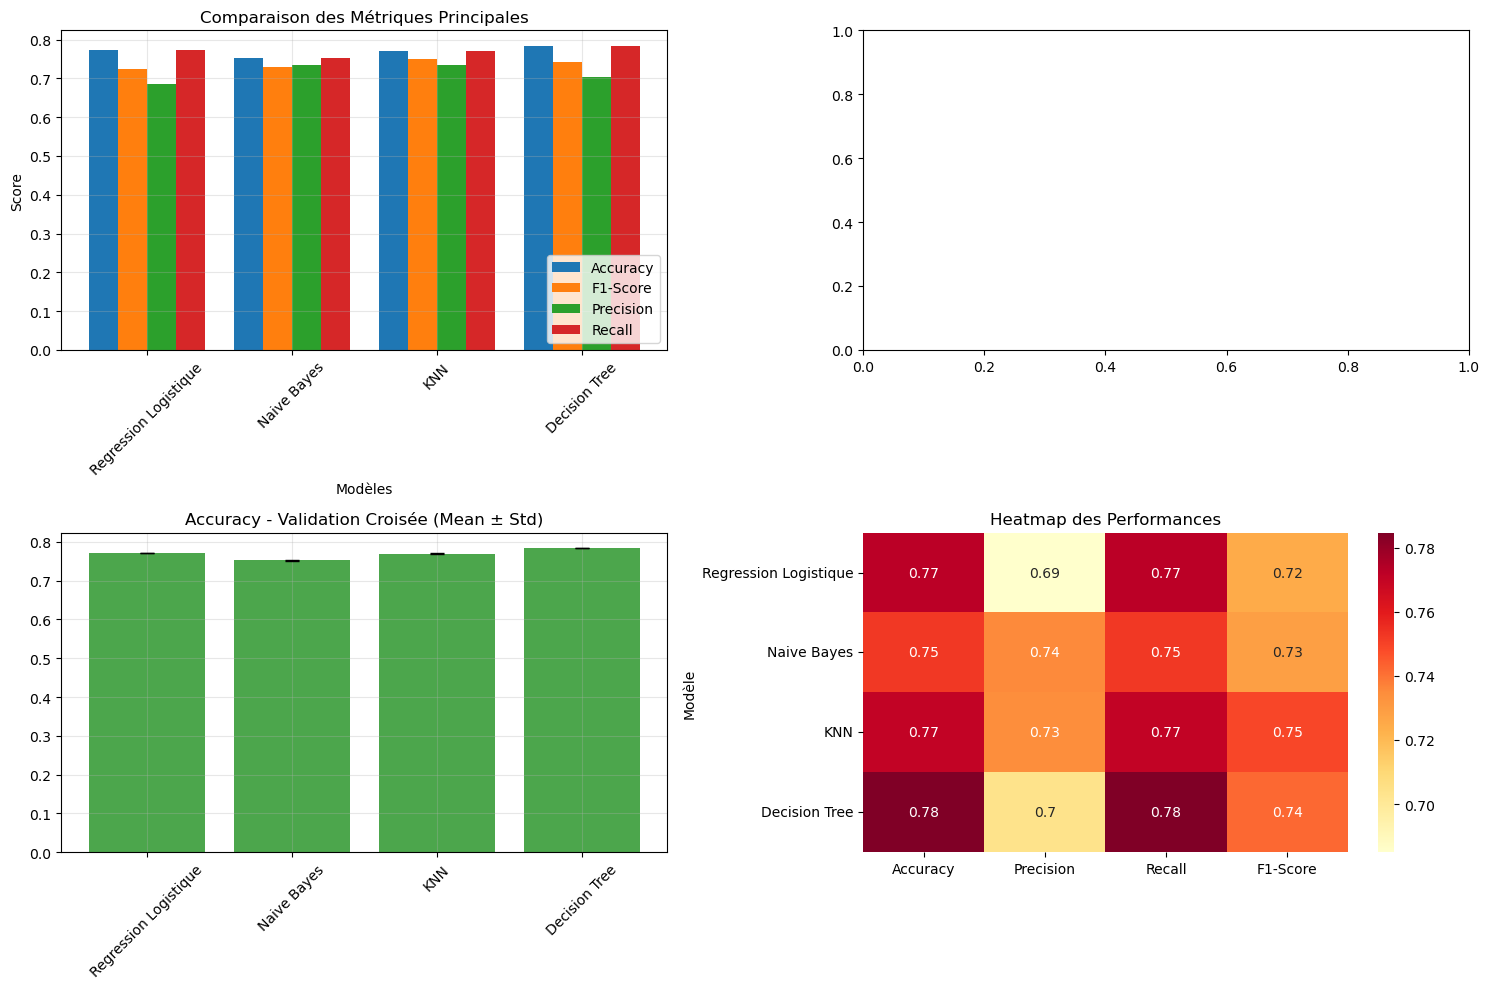

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.772400,0.685000,0.772400,0.724800,0.771900,0.000800
1,Naive Bayes,0.752500,0.735400,0.752500,0.729000,0.752200,0.001200
2,KNN,0.770300,0.734700,0.770300,0.749000,0.769700,0.000900
3,Decision Tree,0.784700,0.703900,0.784700,0.742100,0.784100,0.000700


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7724,0.6850,0.7724,0.7248,0.7719,0.0008
1,Naive Bayes,0.7525,0.7354,0.7525,0.7290,0.7522,0.0012
2,KNN,0.7703,0.7347,0.7703,0.7490,0.7697,0.0009
3,Decision Tree,0.7847,0.7039,0.7847,0.7421,0.7841,0.0007


In [55]:
visualiser_resultats(df_scores)